# Convergence Bounds vs. Maximum Delay B

This experiment examines the relationship between the maximum delay parameter
$B$ and the final distance of the iterates from the nearest global section.

The setup is a 4-regular graph with $n=20$ agents and semi-orthogonal
(rank-1) restriction maps. For each of 15 values of $B = 2^0, 2^1, \ldots, 2^{14}$,
we run three trials of deterministic periodic asynchronous diffusion (one trial
per random phase realization) with step size $\gamma = 1/K$ and report the
average final distance to the nearest global section $\mathbf{x}^*$.

The plot shows that convergence degrades gracefully as $B$ grows, consistent
with the theoretical bound in [CITATION].

**Data source:** Pre-generated by `docs/scripts/acc26_experiments.jl`.

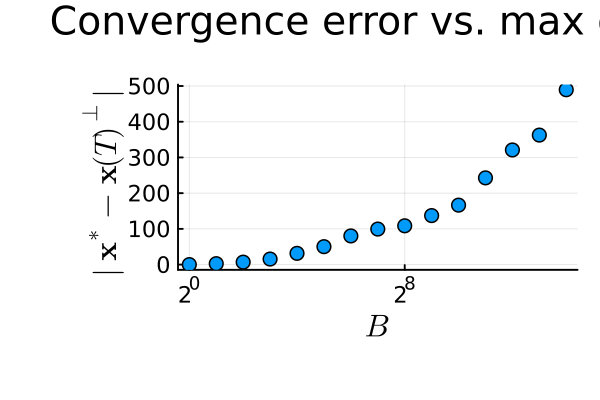

In [1]:
using CellularSheaves
using Plots
using LaTeXStrings

const data_root = joinpath(@__DIR__, "../../../data/asynch/op_experiment")
const results_path = joinpath(data_root, "results.csv")

if isfile(results_path)
    results = vec(load_trajectory(results_path))
    Bs = [2^(i - 1) for i in 1:length(results)]

    scatter(
        Bs, results,
        xscale=:log2,
        xlabel=L"B",
        ylabel=L"\|\mathbf{x}^* - \mathbf{x}(T)^\perp\|",
        label="",
        thickness_scaling=1.9,
        title="Convergence error vs. max delay",
    )
else
    @warn "Data not found at $results_path. Run docs/scripts/acc26_experiments.jl to generate."
    plot(title="Data not generated yet", framestyle=:none)
end